<a href="https://colab.research.google.com/github/SumaiyaZohaRODELA/CKD-NHANES-2021-2023-Staged-Kidney-Diseases_-Data-science/blob/main/risk_finding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
alitaqishah_ckd_nhanes_2021_2023_staged_kidney_disease_path = kagglehub.dataset_download('alitaqishah/ckd-nhanes-2021-2023-staged-kidney-disease')

print('Data source import complete.')

100%|██████████| 372k/372k [00:00<00:00, 68.1MB/s]

Extracting files...
Data source import complete.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy as sp
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

# Load dataset - using the path from earlier in the notebook
# If you intend to use a different dataset, please specify the path.
eda_df = pd.read_csv('/content/drive/MyDrive/data_diabetes/CKD.csv')

print("Dataset Shape:", eda_df.shape)
display(eda_df.head())

Dataset Shape: (11933, 29)


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


### Detect important columns

In [4]:
age_col=[c for c in eda_df.columns if "age" in c.lower()][0]
gender_col=[c for c in eda_df.columns if "gender" in c.lower() or "sex" in c.lower()][0]
egfr_col=[c for c in eda_df.columns if "egfr" in c.lower()][0]

creatinine_col=[c for c in eda_df.columns if "creatinine" in c.lower()]
creatinine_col=creatinine_col[0] if creatinine_col else None

# Create CKD Stages (CLINICALLY MEANINGFUL)

In [5]:
def stage(x):
    if x>=90: return "Normal"
    elif x>=60: return "Mild"
    elif x>=30: return "Moderate"
    else: return "Severe"

eda_df["CKD_Stage"]=eda_df[egfr_col].apply(stage)

 **1️⃣ CKD STAGE DISTRIBUTION (MAIN INSIGHT)**

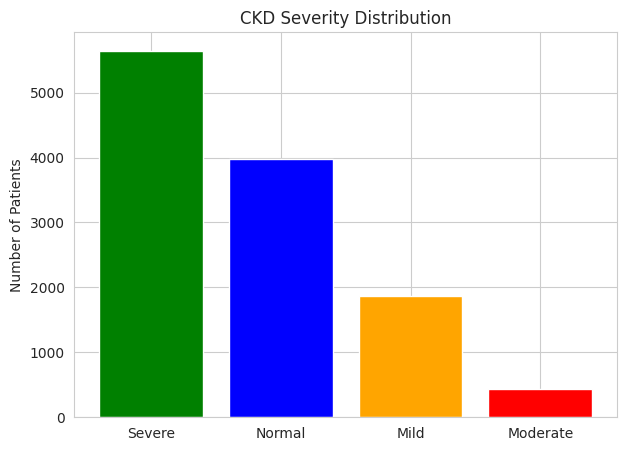

In [6]:
stage_counts=eda_df["CKD_Stage"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(stage_counts.index,stage_counts.values,color=["green","blue","orange","red"])

plt.title("CKD Severity Distribution")

plt.ylabel("Number of Patients")

plt.show()

**2️⃣ AGE vs CKD (VERY IMPORTANT)**

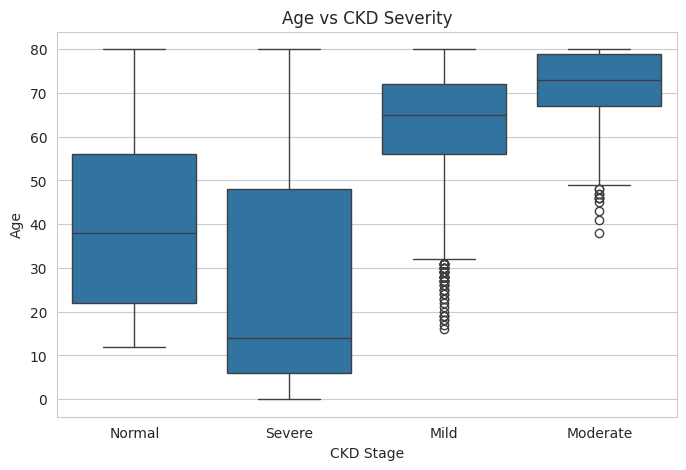

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(data=eda_df,x="CKD_Stage",y=age_col)

plt.title("Age vs CKD Severity")

plt.xlabel("CKD Stage")

plt.ylabel("Age")

plt.show()

**3️⃣ eGFR vs Age**

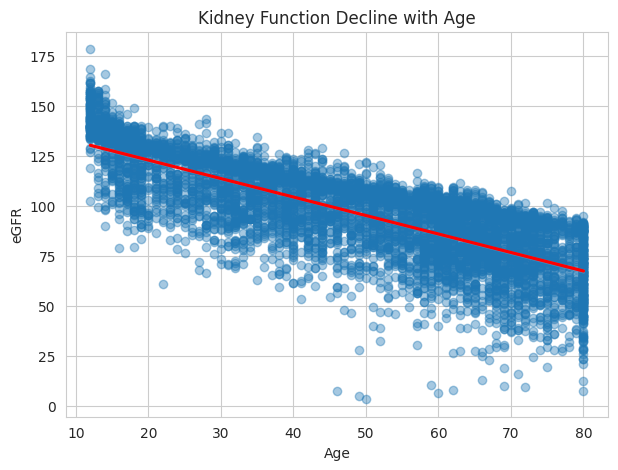

In [8]:
plt.figure(figsize=(7,5))

sns.regplot(x=eda_df[age_col],y=eda_df[egfr_col],
            scatter_kws={"alpha":0.4},
            line_kws={"color":"red"})

plt.title("Kidney Function Decline with Age")

plt.xlabel("Age")

plt.ylabel("eGFR")

plt.show()

# Creatinine vs CKD Stage (MEDICAL MEANING)

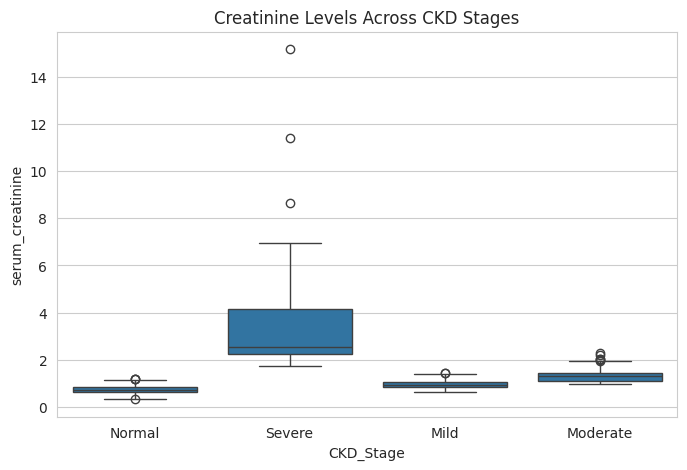

In [9]:
if creatinine_col:

    plt.figure(figsize=(8,5))

    sns.boxplot(data=eda_df,x="CKD_Stage",y=creatinine_col)

    plt.title("Creatinine Levels Across CKD Stages")

    plt.show()

## 5️⃣ Gender vs CKD (RISK GROUP)

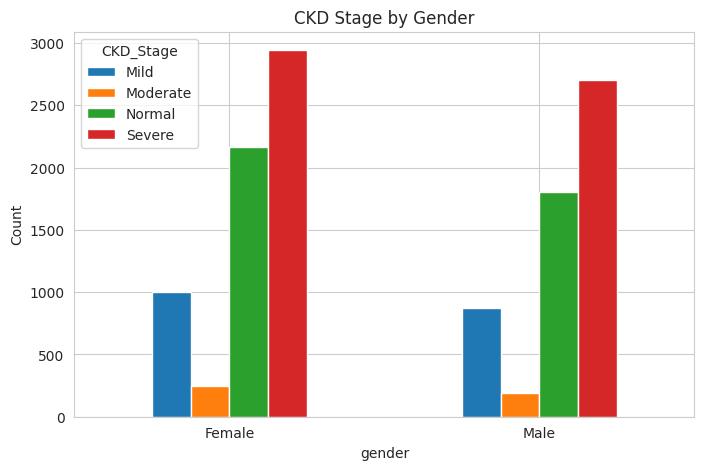

In [10]:
gender_stage=pd.crosstab(eda_df[gender_col],eda_df["CKD_Stage"])

gender_stage.plot(kind="bar",figsize=(8,5))

plt.title("CKD Stage by Gender")

plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

## TABLE: CKD SUMMARY (CLEAR TABLE)

In [11]:
summary=eda_df.groupby("CKD_Stage")[[age_col,egfr_col]].mean()

print("\nAverage Age & eGFR by CKD Stage")
display(summary)


Average Age & eGFR by CKD Stage


,age,egfr
CKD_Stage,,
Mild,62.666667,77.452923
Moderate,71.276256,50.580525
Normal,39.294162,111.445478
Severe,26.987779,21.210000


## FINAL INSIGHT (IMPORTANT)

---



In [12]:
worst=eda_df.loc[eda_df[egfr_col].idxmin()]

print("\n==============================")
print("HIGHEST CKD RISK PATIENT")
print("==============================")

print("Age:",worst[age_col])
print("Gender:",worst[gender_col])
print("eGFR:",worst[egfr_col])

if creatinine_col:
    print("Creatinine:",worst[creatinine_col])


HIGHEST CKD RISK PATIENT
Age: 50.0
Gender: Male
eGFR: 3.51
Creatinine: 15.17
